# Does a mite shrink when it dies?

**The hypothesis:** a mite that dies does not stay as it was. Its legs may fold in and it loses water, so its dark shape on the plate gets smaller. If so, a dead mite can be told from a live one without either of them moving: by comparing its picture now with its own pictures from earlier in the run.

**The test:** the long run (`test_run_2026-09-08_Mathis_last_dsRNA`, 295 recordings 10 minutes apart, every mite labelled in every recording). Each mite's **silhouette** is measured in the mean image of every recording: the sum of how much darker than the plate each pixel is, over the mite. It is followed through the run and set against the mite's last labelled movement.

The measurements are in `scripts/alive_dead_features.py`; `alive_dead_overview.ipynb` sets this hypothesis beside the others that were tried. The patches are those `scripts/optuna_death_time.py` cuts and keeps in the system's temporary folder; the first run cuts them and measures them (a few minutes), later ones start at once.

## Findings (run of 8 October 2026)

These are the numbers of the run saved in this notebook: one run, one plate, 54 mites that moved at least once and 5 that never did.

- **A dead mite's silhouette is smaller than it was alive.** By the end of the run the silhouettes are 7.5% below their highest level in the middle (2.2% to 12.4%). While a mite is alive its silhouette stays where it was (within -1.0% and +1.5% of its start for half the recordings). What goes is the outline: all the way round, most on the side of the legs, the pixels at the mite's edge get about 4 grey levels brighter. That is an outline drawing in by about a fifth of a pixel, which is why nobody sees it in the pictures.
- **It separates alive from dead better than anything else tried.** The silhouette against the highest level the mite has had so far: AUC 0.995 pooled, 1.000 among the mites of the same recording, 0.998 within each mite. With a limit at 4.2% below the highest, 97.4% of the dead recordings are below it and 2.6% of the alive ones (in 11 of the 54 mites).
- **It needs the mite's own past.** Mites differ in size by 13%, more than one shrinks, so the silhouette in pixels says nearly nothing (AUC 0.61).
- **It is slow.** A mite is below the limit, and stays there, 34 recordings (5.7 hours) after its last labelled movement in the middle, and half the mites between 16 and 64 recordings after. It confirms a death hours later; it does not time it.
- **The shrinking starts when the image stops changing, not at the last labelled movement.** In 20 of the 54 mites it starts more than 15 recordings after the last labelled movement (2.7 to 17 hours after). In those stretches in between, the image still changed from one recording to the next in 57% of the recordings, against 88% while alive, 13% while shrinking and 0.3% after. A dead mite's image does not change, so these mites were alive: they moved between the recordings, not within the 0.7 seconds of one.
- **So the last labelled movement dates many deaths too early.** The image last changes 11 recordings (110 minutes) after the last labelled movement in the middle, and more than 20 recordings (200 minutes) after it in 43% of the mites. Half the mites are dead after 8.8 hours by the last movement, after 11.3 hours by the end of change.
- **The mites never labelled moving were probably alive at the start.** The images of three of the five changed in 65% to 95% of the first 20 recordings, and their silhouettes held for 3.5 to 7 hours before falling by 9% to 13%. The other two shrink from the first two hours on.
- **The two mites not shrunk at the end are the last two to die.** Mites 10 and 30 end 4.2% and 2.2% below their highest; their images stopped changing at recordings 209 and 279 of 295.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import alive_dead_features as adf
from optuna_death_time import MAX_PAD

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

# Chart style, as in death_time_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
COLORS = {"alive": ORANGE, "alive_moving": ORANGE, "alive_still": AQUA, "waiting": GREY, "dead": BLUE}
pd.set_option("display.precision", 3)

run = adf.load_run()
table, images = adf.features(run)   # {feature: (mites, recordings)}, and each mite's mean image per recording
group = adf.groups(run)
n_mites, n_recordings = run.moving.shape
last, moved = run.last, run.moved
step = float(np.median(np.diff(run.times)))  # minutes from one recording to the next
print(f"{run.name}: {n_mites} mites, {n_recordings} recordings {step:g} minutes apart; "
      f"{moved.sum()} mites moved at least once, {(~moved).sum()} never")
print("recordings: " + ", ".join(f"{name} {int(mask.sum())}" for name, mask in group.items()))

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings


test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings 10 minutes apart; 54 mites moved at least once, 5 never
recordings: alive 3393, alive_still 2739, alive_moving 651, dead 7191, waiting 5346, never 1475


## The silhouette

In the mean image of a recording, each pixel's **darkness** is the share of the plate's light the mite takes away there (0 on the bare plate, about 0.8 in the middle of a mite). The plate's light is read off the edge of the mite's own patch in that same recording, so a lamp that is brighter or darker in one recording changes nothing. The **silhouette** is the sum of the darkness over the mite's box and 8 pixels around it: the number of pixels the mite would cover if it were black all over. It needs no threshold and counts part-covered pixels by their part, which is what lets it see a change of a fraction of a pixel.

Below, the same sum without dividing by the plate's light, for the mites together: the lamp is dimmer in some recordings, and the raw sum drops with it.

a mite's silhouette at the start: median 83 pixels (65 to 113)


the lamp is dimmer in 25 of 295 recordings, by 4.0 grey levels of 115
in those recordings a mite is 3.44% off its neighbours in time without the division, 0.27% with it; in the others 0.27%


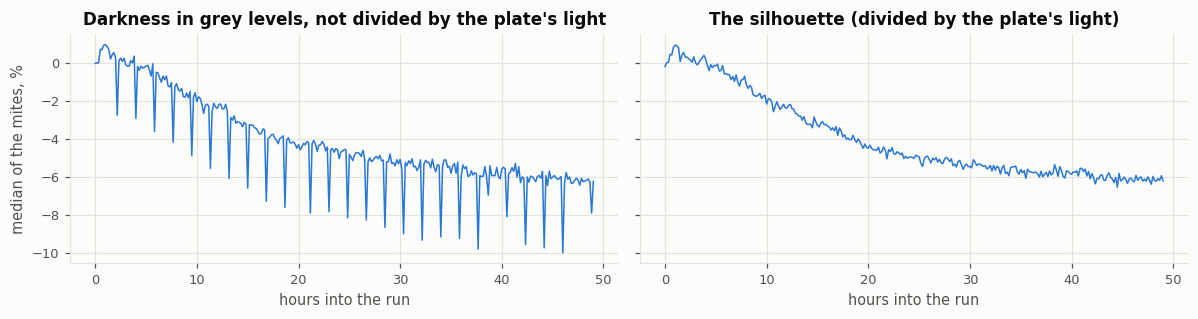

In [2]:
silhouette = table["silhouette"]
shrunk = 100 * adf.since_start(silhouette)       # percent, against the mite's first recordings
edge = MAX_PAD - adf.MARGIN
raw = np.array([np.clip(table["plate"][mite][:, None, None] - image, 0, None)[:, edge:-edge, edge:-edge].sum(axis=(1, 2))
                for mite, image in enumerate(images)])
raw_change = 100 * adf.since_start(raw)
dim = np.median(table["plate"], axis=0) < np.median(table["plate"]) - 2

at_start = np.median(silhouette[:, :adf.BASELINE], axis=1)
print(f"a mite's silhouette at the start: median {np.median(at_start):.0f} pixels ({at_start.min():.0f} to {at_start.max():.0f})")
print(f"the lamp is dimmer in {dim.sum()} of {n_recordings} recordings, by "
      f"{np.median(table['plate'][:, ~dim]) - np.median(table['plate'][:, dim]):.1f} grey levels of {np.median(table['plate']):.0f}")

def off_neighbours(values):
    # how far each recording is from the mean of the one before and the one after
    out = np.full(values.shape, np.nan)
    out[:, 1:-1] = np.abs(values[:, 1:-1] - (values[:, :-2] + values[:, 2:]) / 2)
    return out

print(f"in those recordings a mite is {np.nanmedian(off_neighbours(raw_change)[:, dim]):.2f}% off its neighbours in time "
      f"without the division, {np.nanmedian(off_neighbours(shrunk)[:, dim]):.2f}% with it; "
      f"in the others {np.nanmedian(off_neighbours(shrunk)[:, ~dim]):.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for ax, values, title in ((axes[0], raw_change, "Darkness in grey levels, not divided by the plate's light"),
                          (axes[1], shrunk, "The silhouette (divided by the plate's light)")):
    ax.plot(run.times / 60, np.median(values, axis=0), color=BLUE, linewidth=1)
    ax.set(xlabel="hours into the run", title=title)
axes[0].set_ylabel("median of the mites, %")
plt.tight_layout()
plt.show()

## What it looks like

Twelve mites, each at its last labelled movement and 5, 20, 50 and 100 recordings later. The last two columns are differences of images (red: brighter, blue: darker, the same scale in both):

- **dead - alive**: 100 recordings after the last movement, minus the last 10 recordings up to it;
- **alive - alive**: the last 10 recordings up to the last movement, minus the 10 that end 20 recordings earlier, for comparison.

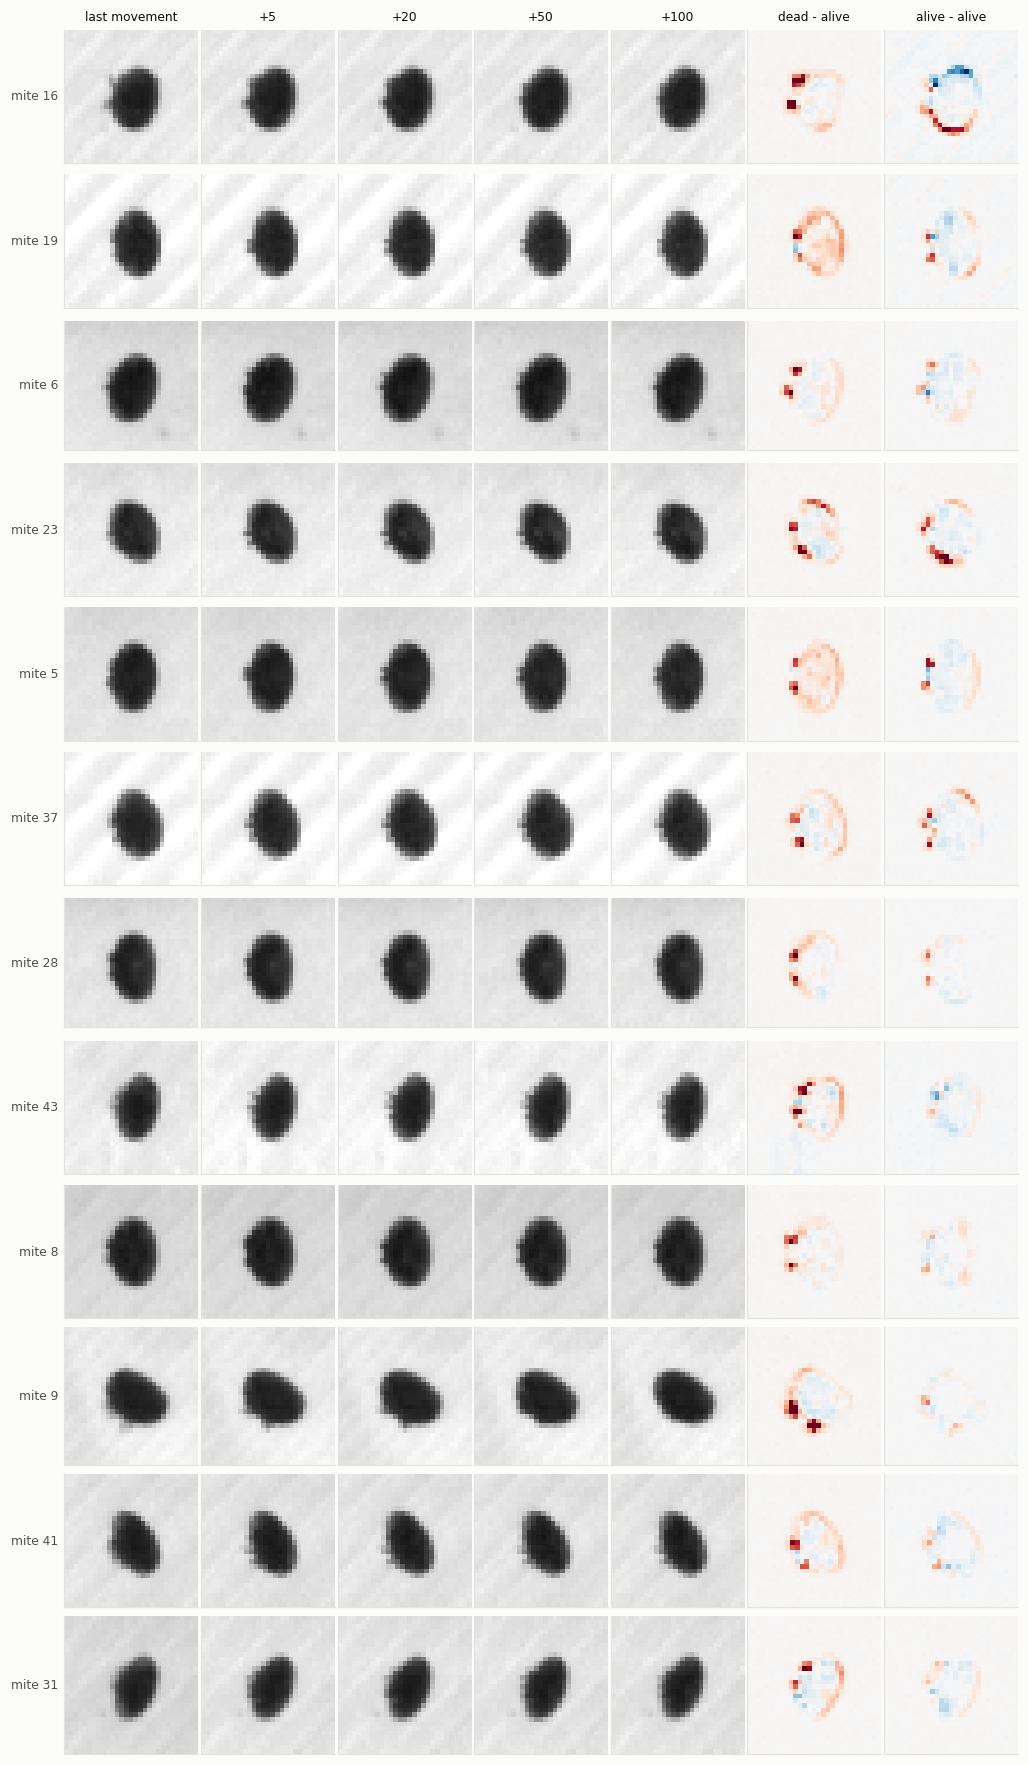

In [3]:
def crop(image, margin=adf.MARGIN):
    edge = MAX_PAD - margin
    return image[..., edge:-edge, edge:-edge]

candidates = [mite for mite in np.argsort(last) if moved[mite] and 30 <= last[mite] <= n_recordings - 111]
shown = candidates[::max(1, len(candidates) // 12)][:12]
offsets = [0, 5, 20, 50, 100]
fig, axes = plt.subplots(len(shown), len(offsets) + 2, figsize=(1.35 * (len(offsets) + 2), 1.35 * len(shown)))
for row, mite in zip(axes, shown):
    at = last[mite]
    for ax, offset in zip(row, offsets):
        ax.imshow(crop(images[mite][at + offset]), cmap="gray", vmin=15, vmax=125)
    alive = images[mite][at - 10:at + 1].mean(axis=0)
    row[-2].imshow(crop(images[mite][at + 100:at + 111].mean(axis=0) - alive), cmap="RdBu_r", vmin=-25, vmax=25)
    row[-1].imshow(crop(alive - images[mite][at - 30:at - 19].mean(axis=0)), cmap="RdBu_r", vmin=-25, vmax=25)
    row[0].set_ylabel(f"mite {run.mites[mite]}", fontsize=8, rotation=0, ha="right", va="center")
for ax, title in zip(axes[0], [f"+{offset}" if offset else "last movement" for offset in offsets] + ["dead - alive", "alive - alive"]):
    ax.set_title(title, fontsize=8, fontweight="normal")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(h_pad=0.2, w_pad=0.2)
plt.show()

The mean of those differences over every mite that can be followed that long, each cut around the mite's centre. A movement puts light where the mite left and dark where it went, which averages out over the mites; a shrinking outline is brighter all the way round.

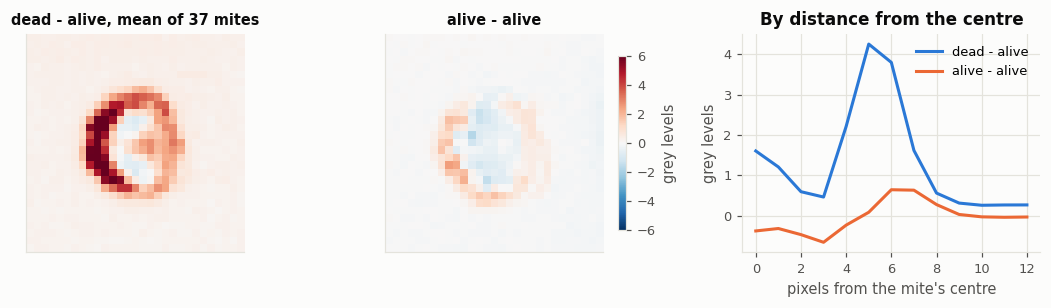

In [4]:
def centred(image, x, y, half=14):
    # the image cut around the mite's centre, to the nearest pixel
    cx, cy = int(round(x)), int(round(y))
    return image[cy - half:cy + half + 1, cx - half:cx + half + 1]

dead_minus_alive, alive_minus_alive = [], []
for mite in np.flatnonzero(moved & (last >= 30) & (last <= n_recordings - 111)):
    at = last[mite]
    x, y = table["x"][mite, at], table["y"][mite, at]
    alive = images[mite][at - 10:at + 1].mean(axis=0)
    dead_minus_alive.append(centred(images[mite][at + 100:at + 111].mean(axis=0) - alive, x, y))
    alive_minus_alive.append(centred(alive - images[mite][at - 30:at - 19].mean(axis=0), x, y))

distance_from_centre = np.hypot(*np.mgrid[-14:15, -14:15])
profile = lambda stack: [np.mean(stack, axis=0)[np.abs(distance_from_centre - radius) < 0.5].mean() for radius in range(13)]
fig, axes = plt.subplots(1, 3, figsize=(10, 2.9))
for ax, stack, title in ((axes[0], dead_minus_alive, f"dead - alive, mean of {len(dead_minus_alive)} mites"),
                         (axes[1], alive_minus_alive, "alive - alive")):
    shown_image = ax.imshow(np.mean(stack, axis=0), cmap="RdBu_r", vmin=-6, vmax=6)
    ax.set_title(title, fontsize=9.5); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(shown_image, ax=axes[1], shrink=0.8, label="grey levels")
axes[2].plot(range(13), profile(dead_minus_alive), color=BLUE, label="dead - alive")
axes[2].plot(range(13), profile(alive_minus_alive), color=ORANGE, label="alive - alive")
axes[2].set(xlabel="pixels from the mite's centre", ylabel="grey levels", title="By distance from the centre")
axes[2].legend()
plt.tight_layout()
plt.show()

## Every mite

One row per mite, sorted by its last labelled movement (the black dot); the colour is the silhouette against the mite's own first recordings. The mites at the top, without a dot, were never labelled moving.

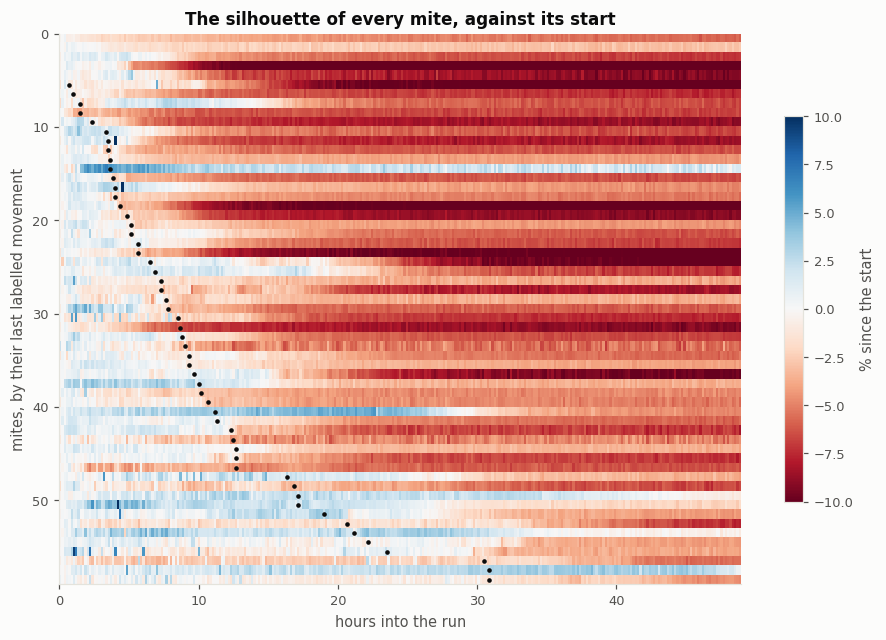

In [5]:
order = np.argsort(last, kind="stable")
fig, ax = plt.subplots(figsize=(10, 6.5))
shown_image = ax.imshow(shrunk[order], aspect="auto", cmap="RdBu", vmin=-10, vmax=10,
                        extent=(0, run.times[-1] / 60, n_mites, 0), interpolation="nearest")
ax.plot(run.times[np.maximum(last[order], 0)][moved[order]] / 60, np.flatnonzero(moved[order]) + 0.5, ".", color=INK, markersize=4)
ax.set(xlabel="hours into the run", ylabel="mites, by their last labelled movement", title="The silhouette of every mite, against its start")
ax.grid(False)
fig.colorbar(shown_image, label="% since the start", shrink=0.7)
plt.show()

## Around the last movement

Every mite's silhouette by the time since its last labelled movement: the middle mite and the middle half of them.

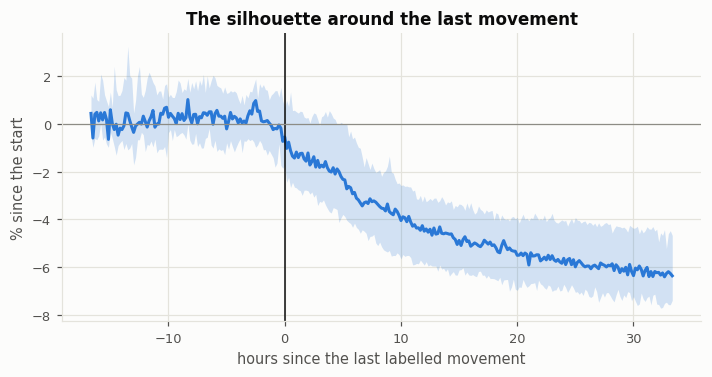

,median %,middle half from,to,mites
recordings since the last movement,,,,
-100 to -50,0.208,-0.837,1.603,29
-50 to -10,0.305,-0.880,1.537,50
-10 to 0,-0.110,-1.401,1.309,54
0 to 10,-1.089,-2.634,0.745,54
10 to 20,-1.613,-3.088,0.304,54
20 to 40,-2.358,-3.928,0.035,54
40 to 80,-3.857,-5.530,-2.133,54
80 to 150,-5.265,-6.570,-3.749,54
150 to 250,-6.274,-7.622,-4.483,51


In [6]:
def aligned(values, reference, chosen):
    # (mites, 2 * recordings): each chosen mite's values, its recording `reference` put at column n_recordings
    out = np.full((len(values), 2 * n_recordings), np.nan)
    for mite in np.flatnonzero(chosen):
        out[mite, n_recordings - reference[mite]:2 * n_recordings - reference[mite]] = values[mite]
    return out

since = np.arange(2 * n_recordings) - n_recordings
around = aligned(shrunk, last, moved)
enough = (np.isfinite(around).sum(axis=0) >= 8) & (since >= -100) & (since <= 200)
low, middle, high = np.nanpercentile(around[:, enough], [25, 50, 75], axis=0)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.fill_between(since[enough] * step / 60, low, high, color=BLUE, alpha=0.2, linewidth=0)
ax.plot(since[enough] * step / 60, middle, color=BLUE)
ax.axvline(0, color=INK, linewidth=1)
ax.axhline(0, color=GREY, linewidth=0.8)
ax.set(xlabel="hours since the last labelled movement", ylabel="% since the start", title="The silhouette around the last movement")
plt.show()

rows = []
for first, end in [(-100, -50), (-50, -10), (-10, 0), (0, 10), (10, 20), (20, 40), (40, 80), (80, 150), (150, 250)]:
    part = around[:, (since >= first) & (since < end)]
    rows.append({"recordings since the last movement": f"{first} to {end}", "median %": np.nanmedian(part),
                 "middle half from": np.nanpercentile(part, 25), "to": np.nanpercentile(part, 75),
                 "mites": int(np.isfinite(part).any(axis=1).sum())})
display(pd.DataFrame(rows).set_index("recordings since the last movement"))

## Alive against dead

**Alive**: the recordings up to a mite's last labelled movement. **Dead**: those 100 recordings (1000 minutes) or more after it, as in `dead_mite_change.ipynb`. **Waiting**: the ones in between. The mites never labelled moving are in none.

Three numbers say how well a measurement separates alive from dead, each an AUC (the chance that an alive recording has the higher value: 0.5 says nothing, 0 or 1 separates fully):

- **AUC**: all the recordings pooled.
- **same time**: alive and dead mites compared within the same recording, then averaged over the recordings. In this run the alive recordings are early and the dead ones late, so anything that drifts with the hours separates them in the pooled AUC without having to do with death. It cannot here. This comparison only exists from recording 104 on, when 8 mites are still alive, so it rests on those 8; the table further down takes the dead from sooner after the last movement, which brings more mites into it.
- **same mite**: each mite's own alive recordings against its own dead ones, then averaged over the mites. Nothing that differs from mite to mite (its size, its place on the plate) can separate them here.

**distance** is the gap between the two medians in units of the two groups' own spread (d').

The silhouette is compared with the mite's own past in two ways:

- **since the start**: against the median of its first 3 recordings. Simple, but a mite whose first recordings were not its usual self (it stood on its legs, it was turned) is held to them for the whole run.
- **below its highest**: against the highest level it has had so far (the highest of its running medians over 5 recordings, `adf.below_highest()`). It only looks back, so it can be had during a run. A live mite's silhouette wanders up and down by a few percent with its posture, so it is a few percent below its highest most of the time; what counts is how far.

,AUC,same time,same mite,distance
"silhouette, below its highest",0.995,1.000,0.998,3.380
"silhouette, since the start",0.962,0.967,0.983,2.984
"area 15% darker than the plate, since the start",0.959,0.978,0.986,2.580
"area 30% darker, since the start",0.947,0.914,0.985,2.267
"size (distance of the darkness from the centre), since the start",0.538,0.489,0.625,0.164
"elongation, since the start",0.305,0.314,0.190,-0.751
"darkness of the 30 darkest pixels, since the start",0.642,0.855,0.520,0.455
"steepness of the outline, since the start",0.539,0.631,0.489,-0.003
"silhouette in pixels, not against the start",0.614,0.541,0.983,0.174
"area 15% darker in pixels, not against the start",0.721,0.771,0.986,0.718


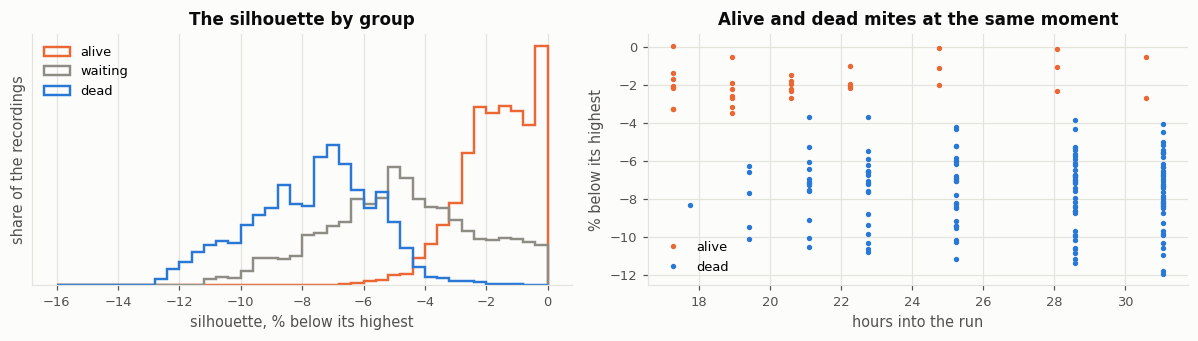

In [7]:
below = 100 * adf.below_highest(silhouette)      # percent, against the mite's highest level so far
candidates = {
    "silhouette, below its highest": below,
    "silhouette, since the start": shrunk,
    "area 15% darker than the plate, since the start": 100 * adf.since_start(table["area_15"]),
    "area 30% darker, since the start": 100 * adf.since_start(table["area_30"]),
    "size (distance of the darkness from the centre), since the start": 100 * adf.since_start(table["size"]),
    "elongation, since the start": 100 * adf.since_start(table["elongation"]),
    "darkness of the 30 darkest pixels, since the start": 100 * adf.since_start(table["peak"]),
    "steepness of the outline, since the start": 100 * adf.since_start(table["edge"]),
    "silhouette in pixels, not against the start": silhouette,
    "area 15% darker in pixels, not against the start": table["area_15"],
}
result = pd.DataFrame({name: adf.separation(values, group["alive"], group["dead"]) for name, values in candidates.items()}).T
display(result.rename(columns={"auc": "AUC", "same_time": "same time", "same_mite": "same mite"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
bins = np.arange(-16, 0.01, 0.4)
for name in ("alive", "waiting", "dead"):
    axes[0].hist(below[group[name]], bins=bins, density=True, histtype="step", linewidth=1.6, color=COLORS[name], label=name)
axes[0].set(xlabel="silhouette, % below its highest", ylabel="share of the recordings", title="The silhouette by group")
axes[0].set_yticks([])
axes[0].legend()

# the same moment of the run: the mites alive and those dead at a few recordings
for at in (105, 115, 125, 135, 150, 170, 185):
    for name, shift in (("alive", -1.5), ("dead", 1.5)):
        values = below[group[name][:, at], at]
        axes[1].plot(np.full(len(values), at + shift) * step / 60, values, ".", color=COLORS[name], markersize=5,
                     label=name if at == 105 else None)
axes[1].set(xlabel="hours into the run", ylabel="% below its highest", title="Alive and dead mites at the same moment")
axes[1].legend()
plt.tight_layout()
plt.show()

The same with a mite taken as dead sooner after its last labelled movement. More live mites are then in the same-time comparison, but the dead ones have had less time to shrink, and some of them are not dead yet (see the three clocks below).

In [8]:
rows = []
for after in (20, 30, 50, 75, 100, 150):
    sooner = adf.groups(run, long_dead=after)
    result = adf.separation(below, sooner["alive"], sooner["dead"])
    compared = (sooner["alive"].sum(axis=0) >= 3) & (sooner["dead"].sum(axis=0) >= 3)   # the recordings with 3 mites on each side
    rows.append({"dead from (recordings after the last movement)": after, "hours": after * step / 60, "AUC": result["auc"],
                 "same time": result["same_time"], "same mite": result["same_mite"],
                 "live mites in the same-time comparison": int(sooner["alive"][:, compared].any(axis=1).sum())})
display(pd.DataFrame(rows).set_index("dead from (recordings after the last movement)"))

,hours,AUC,same time,same mite,live mites in the same-time comparison
dead from (recordings after the last movement),,,,,
20,3.333,0.963,0.898,0.969,40
30,5.000,0.970,0.926,0.976,35
50,8.333,0.981,0.964,0.985,22
75,12.500,0.990,0.994,0.991,12
100,16.667,0.995,1.000,0.998,8
150,25.000,0.998,1.000,0.999,3


### A limit, and what it costs

A mite is called **shrunk** when its silhouette is below a limit, taken where it tells the alive recordings from the dead ones best (sensitivity + specificity).

In [9]:
alive_values, dead_values = below[group["alive"]], below[group["dead"]]
limits = np.arange(-8, 0.01, 0.1)
LIMIT = float(limits[int(np.argmax([(dead_values < limit).mean() + (alive_values >= limit).mean() for limit in limits]))])
below_alive = np.where(group["alive"], below, 0) < LIMIT
print(f"limit: {LIMIT:.1f}% below its highest")
print(f"  dead recordings below it:  {(dead_values < LIMIT).mean():.1%} of {len(dead_values)}")
print(f"  alive recordings below it: {(alive_values < LIMIT).mean():.1%} of {len(alive_values)}, in {int(below_alive.any(axis=1).sum())} "
      f"of {moved.sum()} mites; {int((below_alive.sum(axis=1) >= 10).sum())} mites have 10 or more of them")
final = np.median(below[:, -10:], axis=1)
print(f"by the end of the run {int((final[moved] < LIMIT).sum())} of {moved.sum()} mites that moved are below it; "
      f"their silhouettes ended {-np.median(final[moved]):.1f}% below their highest in the middle ({-final[moved].max():.1f} to {-final[moved].min():.1f})")
print("  not below it: " + ", ".join(f"mite {run.mites[m]} ({final[m]:+.1f}%, last movement at recording {last[m]})"
                                     for m in np.flatnonzero(moved & (final >= LIMIT))))

# how long after the last movement a mite is below the limit, and stays there for 5 recordings
lasting = [np.convolve(row < LIMIT, np.ones(5), "valid") == 5 for row in below]
crossing = np.array([np.argmax(row) if row.any() else -1 for row in lasting])
wait = (crossing - last)[moved & (crossing >= 0)]
print(f"a mite is first below it for 5 recordings in a row {np.median(wait):.0f} recordings ({np.median(wait) * step / 60:.1f} hours) "
      f"after its last labelled movement in the middle (middle half: {np.percentile(wait, 25):.0f} to {np.percentile(wait, 75):.0f}); "
      f"{int((wait < 0).sum())} mites before it, {int((moved & (crossing < 0)).sum())} never")

around_below = aligned(below, last, moved)
rows = []
for first, end in [(0, 10), (10, 20), (20, 40), (40, 60), (60, 100), (100, 150), (150, 300)]:
    part = around_below[:, (since >= first) & (since < end)]
    rows.append({"recordings since the last movement": f"{first} to {end}", "hours": f"{first * step / 60:.1f} to {end * step / 60:.1f}",
                 "below the limit": f"{np.mean(part[np.isfinite(part)] < LIMIT):.0%}"})
display(pd.DataFrame(rows).set_index("recordings since the last movement"))

limit: -4.2% below its highest
  dead recordings below it:  97.4% of 7191
  alive recordings below it: 2.6% of 3393, in 11 of 54 mites; 5 mites have 10 or more of them
by the end of the run 52 of 54 mites that moved are below it; their silhouettes ended 7.5% below their highest in the middle (2.2 to 12.4)
  not below it: mite 10 (-4.2%, last movement at recording 103), mite 30 (-2.2%, last movement at recording 185)
a mite is first below it for 5 recordings in a row 34 recordings (5.7 hours) after its last labelled movement in the middle (middle half: 16 to 64); 3 mites before it, 2 never


,hours,below the limit
recordings since the last movement,,
0 to 10,0.0 to 1.7,16%
10 to 20,1.7 to 3.3,23%
20 to 40,3.3 to 6.7,43%
40 to 60,6.7 to 10.0,65%
60 to 100,10.0 to 16.7,84%
100 to 150,16.7 to 25.0,96%
150 to 300,25.0 to 50.0,98%


## Three clocks for one death

The shrinking does not start at the last labelled movement in every mite: in some it starts dozens of recordings later. Either those mites lie dead for hours before they shrink, or they are alive for hours after the last movement anyone saw. A third measurement decides between the two: `dead_mite_change.ipynb` showed that a live mite's image changes from one recording to the next even when it is still in both, and that the image of a long dead one does not. So each mite gets three times:

- **last movement**: the last recording labelled moving (what the survival analysis goes by);
- **end of change**: the last recording whose image differs from the one before by more than the camera's noise allows, the pair before it too (`adf.last_change()`, the limit as in `dead_mite_change.ipynb`);
- **shrink onset**: where the silhouette leaves its level and starts to fall (`adf.shrink_onset()`: a level, then a fall that slows down, fitted to each mite).

The first is what a person saw within the 0.7 seconds of a recording. The other two are read off the mean images. They do not measure the same thing: one is whether the image differs from the one before, in any direction; the other is the sum of the darkness, which a mite that only moves leaves as it is.

an image has changed when it differs from the one before by more than 0.75 grey levels


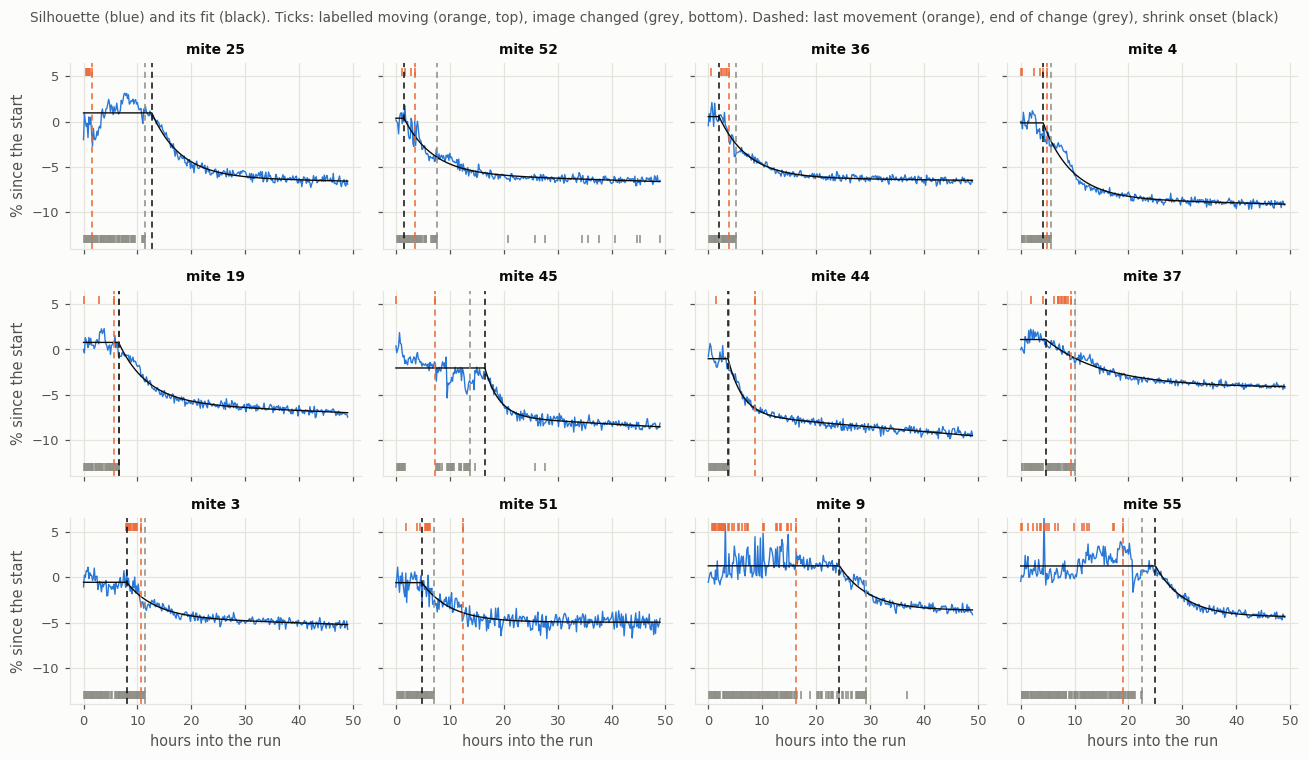

In [10]:
still_floor = table["noise_floor"][run.labelled & ~run.moving]
CHANGE_LIMIT = float(np.percentile(still_floor, 99.9))
change = table["image_change"]
end_of_change = adf.last_change(change, CHANGE_LIMIT)
fits = [adf.shrink_onset(shrunk[mite]) for mite in range(n_mites)]
onset = np.array([fit[0] for fit in fits])
print(f"an image has changed when it differs from the one before by more than {CHANGE_LIMIT:.2f} grey levels")

def draw_mite(ax, mite, marks=True):
    ax.plot(run.times / 60, shrunk[mite], color=BLUE, linewidth=0.9)
    ax.plot(run.times / 60, fits[mite][1], color=INK, linewidth=0.9)
    changed = np.flatnonzero(np.nan_to_num(change[mite]) > CHANGE_LIMIT)
    ax.plot(run.times[changed] / 60, np.full(len(changed), -13.0), "|", color=GREY, markersize=5)
    labelled_moving = np.flatnonzero(run.moving[mite])
    ax.plot(run.times[labelled_moving] / 60, np.full(len(labelled_moving), 5.5), "|", color=ORANGE, markersize=5)
    for at, color in ((last[mite], ORANGE), (end_of_change[mite], GREY), (onset[mite], INK)) if marks else ():
        ax.axvline(run.times[at] / 60, color=color, linewidth=1, linestyle=(0, (4, 3)))
    ax.set_title(f"mite {run.mites[mite]}", fontsize=9)
    ax.set_ylim(-14, 6.5)

shown = [mite for mite in np.argsort(last) if moved[mite]][2::4][:12]
fig, axes = plt.subplots(3, 4, figsize=(12, 7), sharex=True, sharey=True)
for ax, mite in zip(axes.ravel(), shown):
    draw_mite(ax, mite)
for ax in axes[-1]:
    ax.set_xlabel("hours into the run")
for ax in axes[:, 0]:
    ax.set_ylabel("% since the start")
fig.suptitle("Silhouette (blue) and its fit (black). Ticks: labelled moving (orange, top), image changed (grey, bottom). "
             "Dashed: last movement (orange), end of change (grey), shrink onset (black)", fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

,median,middle half from,to,median distance,within 5,more than 20 later,more than 20 earlier
in recordings,,,,,,,
end of change - last movement,11.0,6.0,43.00,14.0,20%,43%,4%
shrink onset - last movement,3.5,-14.5,34.25,22.0,17%,35%,17%
shrink onset - end of change,-11.0,-23.5,-2.25,14.0,19%,4%,28%


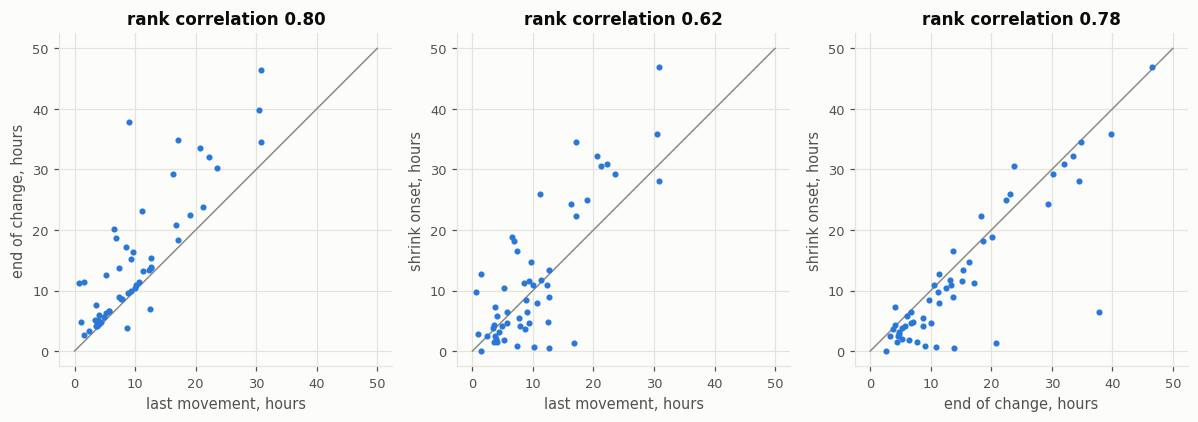

In [11]:
from scipy.stats import spearmanr

def compare(name, difference):
    return {"in recordings": name, "median": np.median(difference), "middle half from": np.percentile(difference, 25),
            "to": np.percentile(difference, 75), "median distance": np.median(np.abs(difference)),
            "within 5": f"{np.mean(np.abs(difference) <= 5):.0%}",
            "more than 20 later": f"{np.mean(difference > 20):.0%}", "more than 20 earlier": f"{np.mean(difference < -20):.0%}"}

display(pd.DataFrame([compare("end of change - last movement", (end_of_change - last)[moved]),
                      compare("shrink onset - last movement", (onset - last)[moved]),
                      compare("shrink onset - end of change", (onset - end_of_change)[moved])]).set_index("in recordings"))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (a, b, name_a, name_b) in zip(axes, ((last, end_of_change, "last movement", "end of change"),
                                             (last, onset, "last movement", "shrink onset"),
                                             (end_of_change, onset, "end of change", "shrink onset"))):
    ax.plot([0, 50], [0, 50], color=GREY, linewidth=1)
    ax.plot(run.times[a[moved]] / 60, run.times[b[moved]] / 60, ".", color=BLUE, markersize=6)
    ax.set(xlabel=f"{name_a}, hours", ylabel=f"{name_b}, hours",
           title=f"rank correlation {spearmanr(a[moved], b[moved])[0]:.2f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Between the last movement and the shrinking

If a mite lay dead between its last labelled movement and the start of its shrinking, its image would not change in that stretch. Below, the share of the recordings whose image changed from the one before, in four stretches of each mite's run.

In [12]:
recording = np.arange(n_recordings)[None]
start = np.maximum(onset, last + 1)[:, None]
stretches = {
    "alive: up to the last labelled movement": moved[:, None] & (recording >= 1) & (recording <= last[:, None]),
    "in between: after the last movement, before the shrink onset": moved[:, None] & (recording > last[:, None] + 1) & (recording < onset[:, None]),
    "shrinking: the 40 recordings from the onset": moved[:, None] & (recording > start) & (recording <= start + 40),
    "after: 100 recordings or more past the onset": moved[:, None] & (recording > start + 100),
}
rows = []
for name, mask in stretches.items():
    values = change[mask & np.isfinite(change)]
    rows.append({"stretch": name, "recordings": len(values), "mites": int(mask.any(axis=1).sum()),
                 "image changed": f"{(values > CHANGE_LIMIT).mean():.1%}", "median change": np.median(values)})
display(pd.DataFrame(rows).set_index("stretch"))

late = np.flatnonzero(moved & (onset - last > 15))
rows = [{"mite": run.mites[m], "last movement": last[m], "end of change": end_of_change[m], "shrink onset": onset[m],
         "hours in between": (onset[m] - last[m]) * step / 60,
         "image changed in between": f"{(change[m, last[m] + 2:onset[m]] > CHANGE_LIMIT).mean():.0%}"} for m in late]
print(f"the {len(late)} mites whose shrinking starts more than 15 recordings after their last labelled movement:")
display(pd.DataFrame(rows).set_index("mite"))

,recordings,mites,image changed,median change
stretch,,,,
alive: up to the last labelled movement,3339,54,88.1%,1.361
"in between: after the last movement, before the shrink onset",1069,28,57.5%,0.812
shrinking: the 40 recordings from the onset,2132,54,12.9%,0.493
after: 100 recordings or more past the onset,6107,51,0.3%,0.487


the 20 mites whose shrinking starts more than 15 recordings after their last labelled movement:


,last movement,end of change,shrink onset,hours in between,image changed in between
mite,,,,,
0,124,201,193,11.500,81%
9,98,176,146,8.000,33%
10,103,209,207,17.333,71%
11,141,181,176,5.833,70%
16,31,75,63,5.333,43%
25,9,68,76,11.167,71%
29,133,192,185,8.667,56%
30,185,279,282,16.167,74%
31,127,143,183,9.333,26%


### The mites never labelled moving

They are left out of the survival numbers, as they may have been dead from the start. Their silhouettes and their image changes say whether they were.

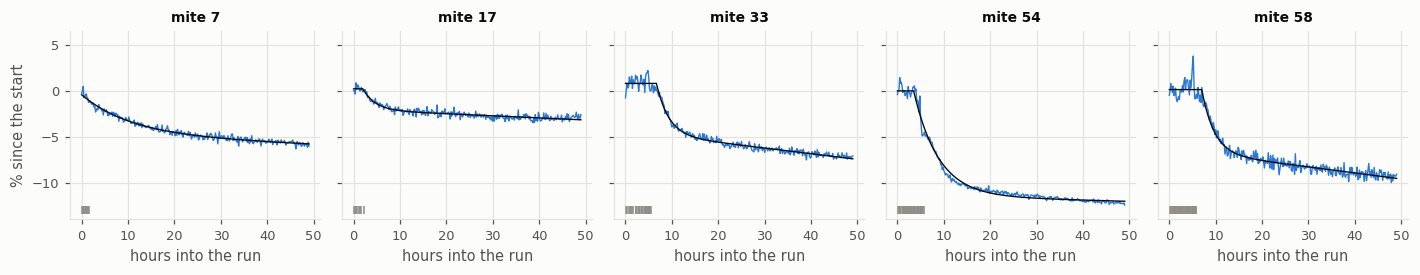

,"end of change, hours","shrink onset, hours",image changed in the first 20 recordings,"below its highest at the end, %"
mite,,,,
7,1.500,0.000,40%,-5.607
17,1.500,2.000,40%,-3.428
33,5.500,6.667,65%,-8.972
54,5.667,3.500,95%,-12.955
58,5.833,7.000,95%,-10.520


In [13]:
never = np.flatnonzero(~moved)
fig, axes = plt.subplots(1, len(never), figsize=(2.6 * len(never), 2.6), sharey=True)
for ax, mite in zip(axes, never):
    draw_mite(ax, mite, marks=False)
    ax.set_xlabel("hours into the run")
axes[0].set_ylabel("% since the start")
plt.tight_layout()
plt.show()
display(pd.DataFrame([{"mite": run.mites[m], "end of change, hours": run.times[end_of_change[m]] / 60,
                       "shrink onset, hours": run.times[onset[m]] / 60,
                       "image changed in the first 20 recordings": f"{(change[m, 1:21] > CHANGE_LIMIT).mean():.0%}",
                       "below its highest at the end, %": final[m]} for m in never]).set_index("mite"))

## How it could be used, and what is not known

**How it could be used**

- **To check the deaths at the end of a run.** Every mite called dead for more than a day should be shrunk. One that is not either died late or is not dead; one that is shrunk and still called alive is worth a look. This needs one number per mite and recording, from the mean image the analysis already has in hand, and no label.
- **To bring the mites never seen moving into the study.** A mite whose silhouette holds for hours and then falls was alive at the start, whatever its movement scores say.
- **Together with the image change between recordings** (`dead_mite_change.ipynb`). The two are wrong in different places: of the alive recordings whose image did not change, 95% are not shrunk (`alive_dead_overview.ipynb`). The change says that a mite did something in the last 10 minutes; the silhouette says that it has been dead for hours.
- **Not to time a death.** The onset fitted here is 14 recordings from the end of change in the middle, and earlier than it more often than later: in some mites the silhouette already falls slowly while the image still changes. Whether those mites shrink while dying or only change their posture, the fit cannot tell.

**What is not known**

- **Whether it holds elsewhere.** This is one run on one plate. How fast a mite shrinks will depend on the air in the box (most of the fall takes about 10 hours here), and perhaps on what the mite was treated with. The three short datasets cover 25 minutes each and cannot show it.
- **When the mites really died.** There is no ground truth for death, only for movement within a recording. That the end of change and the shrinking agree with each other, and disagree with the last labelled movement in the same direction, is evidence that the mites live on after it; it is not a measurement of the time of death.
- **Why it shrinks.** It is the body's outline that draws in, not the legs (`alive_dead_legs.ipynb` splits the two). Whether that is loss of water or the body settling, the pictures cannot say.
- **Where the baseline should be.** The highest level so far works here because every mite is alive at the start. A mite already dead and shrunk when the run starts has nothing to fall from, and would look alive by its silhouette for the whole run.